In [71]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [72]:
# Load Dataset

file_path = "dataset-tickets-multi-lang-4-20k.csv"
df = pd.read_csv(file_path)
print(f"✅ Dataset Loaded Successfully. Shape: {df.shape}")
df[['subject', 'body', 'queue', 'priority', 'language']].head()

✅ Dataset Loaded Successfully. Shape: (20000, 15)


,subject,body,queue,priority,language
0,Unvorhergesehener Absturz der Datenanalyse-Pla...,Die Datenanalyse-Plattform brach unerwartet ab...,General Inquiry,low,de
1,Customer Support Inquiry,Seeking information on digital strategies that...,Customer Service,medium,en
2,Data Analytics for Investment,I am contacting you to request information on ...,Customer Service,medium,en
3,Krankenhaus-Dienstleistung-Problem,Ein Medien-Daten-Sperrverhalten trat aufgrund ...,Customer Service,high,de
4,Security,"Dear Customer Support, I am reaching out to in...",Customer Service,medium,en


In [73]:
# Text + Target Column Prepare
df = df.dropna(subset=['body'])
df['subject'] = df['subject'].fillna('')
df['text'] = df['subject'] + ' ' + df['body']

TEXT_COL = 'text'
LABEL_COL = 'queue'
print(f"✅ Missing values handled. Remaining rows: {df.shape[0]}")

✅ Missing values handled. Remaining rows: 19998


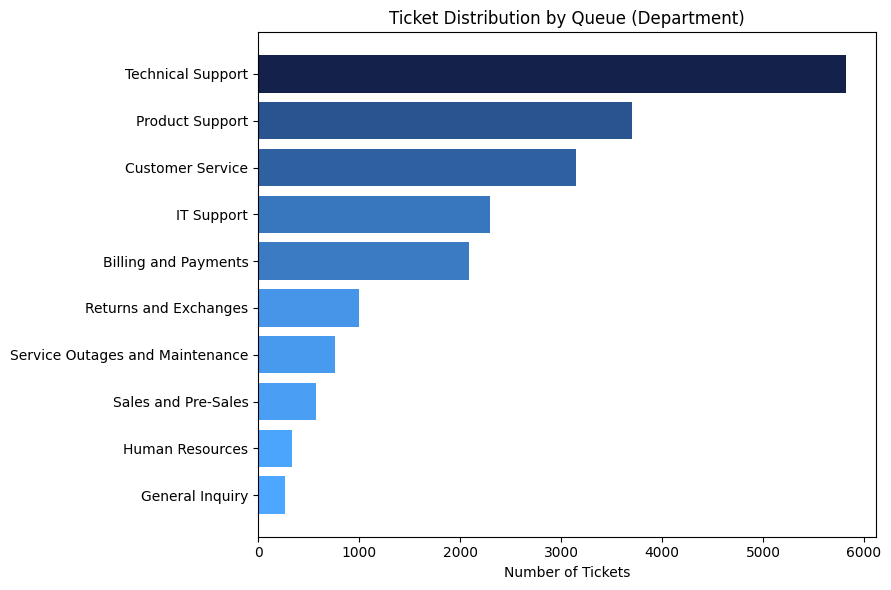

In [74]:
# GRAPH 1: Queue distribution

counts = df['queue'].value_counts().sort_values()
norm_raw = mcolors.Normalize(vmin=counts.values.min(), vmax=counts.values.max())
black_blue_cmap = mcolors.LinearSegmentedColormap.from_list("black_blue", ["#0a0a2a", "#4da6ff"])

# (1 - norm_raw(v)) isliye lagaya hai taaki bada value -> dark end (0) ki taraf jaaye
bar_colors = [black_blue_cmap(0.15 + 0.85 * (1 - norm_raw(v))) for v in counts.values]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(counts.index, counts.values, color=bar_colors)
ax.set_xlabel("Number of Tickets")
ax.set_title("Ticket Distribution by Queue (Department)")
plt.tight_layout()
plt.savefig('queue_distribution.png', dpi=150)
plt.show()

In [75]:
# Text Cleaning

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\w*\d\w*', '', text)
    return text.strip()

df['clean_text'] = df[TEXT_COL].apply(clean_text)
print("✅ Data cleaning done — text lowercased, URLs/HTML/punctuation/numbers removed.")


✅ Data cleaning done — text lowercased, URLs/HTML/punctuation/numbers removed.


In [76]:
# Train-Test Split

X = df['clean_text']
y = df[LABEL_COL]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"✅ Train-test split done. Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

✅ Train-test split done. Train size: 15998, Test size: 4000


In [77]:
# TF-IDF Vectorization

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print(f"✅ TF-IDF vectorization done. Feature count: {X_train_tfidf.shape[1]}")

✅ TF-IDF vectorization done. Feature count: 5000


In [78]:
# Model Training & Evaluation

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(dual='auto')
}

results = {}
predictions = {}
print("\n" + "="*50)
print(" MODEL TRAINING & EVALUATION RESULTS ")
print("="*50)

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    predictions[name] = y_pred

    print(f"\n---> {name} <---")
    print(f"Accuracy: {acc * 100:.2f}%")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("-" * 50)

best_model_name = max(results, key=results.get)
print(f"\nBest Performing Model: {best_model_name} with {results[best_model_name]*100:.2f}% accuracy.")


 MODEL TRAINING & EVALUATION RESULTS 

---> Logistic Regression <---
Accuracy: 42.10%
                                 precision    recall  f1-score   support

           Billing and Payments       0.75      0.63      0.69       417
               Customer Service       0.34      0.35      0.34       631
                General Inquiry       0.00      0.00      0.00        53
                Human Resources       1.00      0.12      0.21        68
                     IT Support       0.33      0.12      0.17       458
                Product Support       0.33      0.32      0.33       741
          Returns and Exchanges       0.69      0.04      0.08       200
            Sales and Pre-Sales       0.83      0.04      0.08       114
Service Outages and Maintenance       0.88      0.23      0.36       153
              Technical Support       0.41      0.73      0.53      1165

                       accuracy                           0.42      4000
                      macro avg    

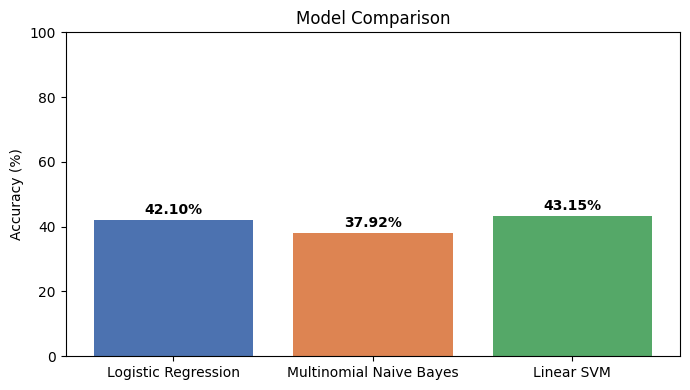

In [79]:
# GRAPH 2: Model comparison

results_pct = {name: acc * 100 for name, acc in results.items()}
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(results_pct.keys(), results_pct.values(), color=['#4C72B0', '#DD8452', '#55A868'])
ax.set_ylabel("Accuracy (%)")
ax.set_title("Model Comparison")
ax.set_ylim(0, 100)
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%",
             ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

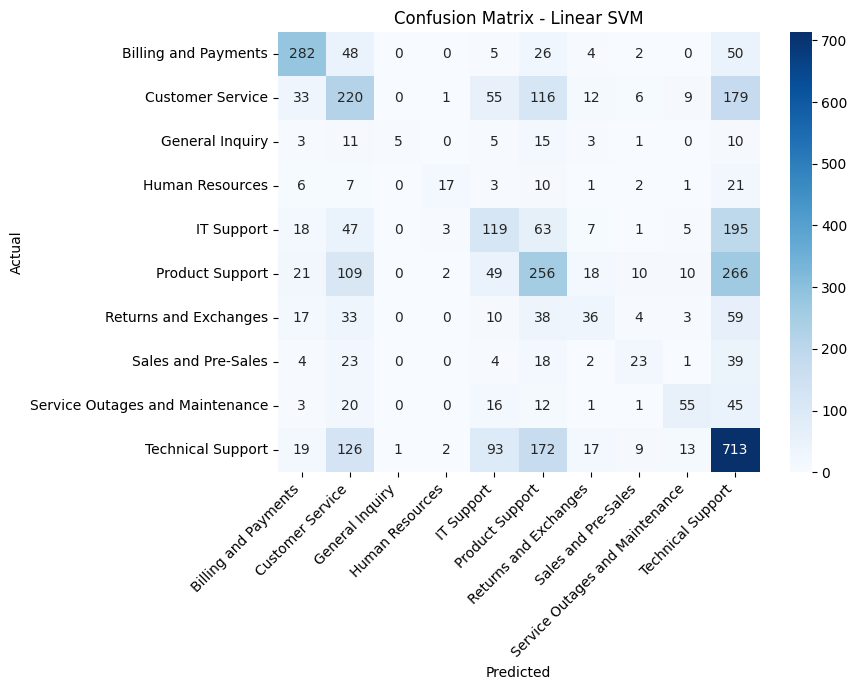

In [80]:
# GRAPH 3: Confusion matrix (best model)

cm_matrix = confusion_matrix(y_test, predictions[best_model_name], labels=sorted(y.unique()))
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()), ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix - {best_model_name}")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()